In [ ]:
import torch
from core.utils import show_masks, gray_to_sam_input
from core.utils import load_image
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

In [17]:
model_type = "vit_b"
checkpoint = "weights/sam_vit_b_01ec64.pth"

# model setup
device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry[model_type](checkpoint=checkpoint)
sam.to(device)
sam.eval()
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    # points_per_side=32,
    # min_mask_region_area=6000
)


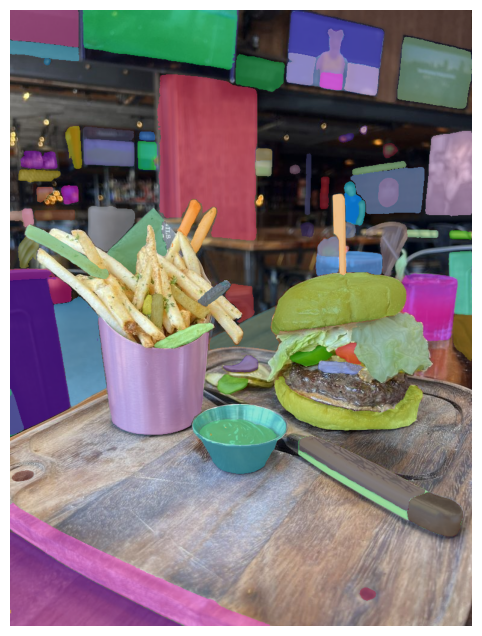

In [18]:
image_path = "photos/wood_dish_1.png"
# image_path = "photos/ok_light_1.png"
# image_path = "photos/good_light_1.png"
image = load_image(image_path)
masks = mask_generator.generate(image)
show_masks(masks, image)